## Functions

In [167]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'
import plotly.express as px
import re
import pickle
import gzip
import pandas as pd
import sys
sys.path.append('../../ViDa') 


import imp, vida.data_processing.strandReorder
imp.reload(vida.data_processing.strandReorder)
from vida.data_processing.strandReorder import *

# import imp, vida.data_processing.utils
# imp.reload(vida.data_processing.utils)
# from vida.data_processing.utils import *

import imp, vida.adjmat.dp2adj
imp.reload(vida.adjmat.dp2adj)
from vida.adjmat.dp2adj import *

import imp, vida.data_processing.comp_time
imp.reload(vida.data_processing.comp_time)
from vida.data_processing.comp_time import *


In [168]:
def loadTimeData(datafile):
    inpath = f'../data/post_data/{datafile}/preprocess_{datafile}.npz'
    loaded_data = np.load(inpath, allow_pickle=True)
    trans_time = loaded_data["trans_time"]
    
    inpath2 = f'../data/post_data/{datafile}/time_{datafile}.npz'
    loaded_data2 = np.load(inpath2, allow_pickle=True)
    trj_id = loaded_data2['trj_id']

    rxnTimes = trans_time[trj_id]
    ids = np.arange(rxnTimes.shape[0])
    # sortTimes = np.sort(rxnTimes)[::-1]
    # sortIDs = ids[np.argsort(rxnTimes)[::-1]]
        
    return rxnTimes, ids



def loadStateData(datafile):
    
    inpath = f'../data/post_data/{datafile}/{datafile}.pkl.gz'
    with gzip.open(inpath, 'rb') as file:
        loaded_data = pickle.load(file)
    trajs_states = loaded_data['trajs_states']
    trajs_shortnames = loaded_data['trajs_shortnames']
        
    return trajs_states, trajs_shortnames



def timeCDF(datafile, rxnTimes):
    
    sort_time = np.sort(rxnTimes)
    cumulative_fraction = np.arange(1, len(sort_time) + 1) / len(sort_time)

    plt.plot(sort_time, cumulative_fraction, '-', color='black', linewidth=2)
    plt.title(f'CDF of Reaction Times: {datafile}')
    # plt.title(f'CDF of Reaction Times (Machinek-Perfect)')
    
    plt.xlabel('Reaction Time (s)')
    plt.ylabel('Cumulative Fraction of Simulated Trajectories') 
    plt.xscale('log')
    plt.grid(True)
    plt.show()

    print('Max reaction time:', np.max(rxnTimes), 'seconds')
    print('Min reaction time:', np.min(rxnTimes), 'seconds')
    print('Average reaction time:', np.mean(rxnTimes), 'seconds')
    print('Median reaction time:', np.median(rxnTimes), 'seconds')
    # thres = np.float64(1e-2)
    # print(f'Number of reaction slower than {thres}:', np.where(rxnTimes > thres)[0].shape[0])
    # print(f'Number of reaction faster than {thres}:', np.where(rxnTimes < thres)[0].shape[0])


def if_detachment(trajs_shortname):
    detach = 0
    see_attach = False

    for sname in trajs_shortname:
        if sname.count("+") == 2:
            see_attach = True
        elif sname.count("+") == 1 and see_attach:
            detach += 1
            break
        else:
            continue
        
    return detach

## Machinek-Perfect

### Time distribution sort

In [159]:
datafile = 'Machinek-PRF'
rxnTimes, ids = loadTimeData(datafile)

In [26]:
# fig = px.scatter(x=ids, y=sortTimes, hover_data=[sortIDs], log_y=True)
# # fig = px.scatter(x=ids, y=sortTimes, hover_data=[sortIDs])

# # plot a horizontal line for the average time
# fig.add_hline(y=np.mean(rxnTimes), line_dash="dot", line_color="red")
# fig.add_hline(y=1e-2, line_dash="dot", line_color="green")

# fig.show()

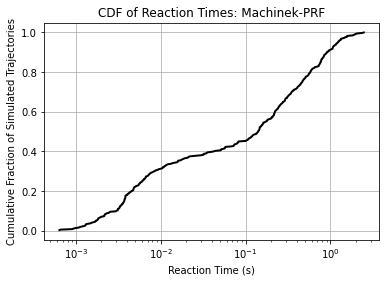

Max reaction time: 2.4719820372770687 seconds
Min reaction time: 0.0006404025694753318 seconds
Average reaction time: 0.31602669386911414 seconds
Median reaction time: 0.14070118945995877 seconds


In [160]:
timeCDF(datafile, rxnTimes)

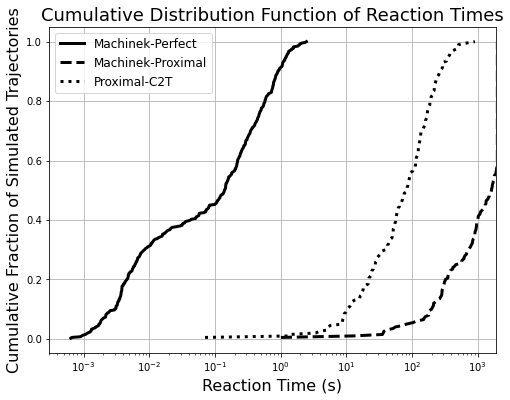

In [208]:
datafile = 'Machinek-PRF'
rxnTimes1, ids = loadTimeData(datafile)
sort_time1 = np.sort(rxnTimes1)
cumulative_fraction1 = np.arange(1, len(sort_time1) + 1) / len(sort_time1)

datafile = 'Machinek-Mismatch2'
rxnTimes2, ids = loadTimeData(datafile)
sort_time2 = np.sort(rxnTimes2)
cumulative_fraction2 = np.arange(1, len(sort_time2) + 1) / len(sort_time2)

datafile = 'Machinek-Mismatch2C2T'
rxnTimes3, ids = loadTimeData(datafile)
sort_time3 = np.sort(rxnTimes3)
cumulative_fraction3 = np.arange(1, len(sort_time3) + 1) / len(sort_time3)

colors = plt.cm.Set1.colors 
color1 = colors[7]
color2 = colors[3]
color3 = colors[4]

plt.figure(figsize=(8, 6))
plt.plot(sort_time1, cumulative_fraction1, '-', color='black', linewidth=3)
plt.plot(sort_time2, cumulative_fraction2, '--', color='black', linewidth=3)
plt.plot(sort_time3, cumulative_fraction3, ':', color='black', linewidth=3)
plt.xlim(3e-4, 1880)
plt.legend(['Machinek-Perfect', 'Machinek-Proximal', 'Proximal-C2T'], fontsize=12)

plt.title(f'Cumulative Distribution Function of Reaction Times', fontsize=18)
# plt.title(f'CDF of Reaction Times (Machinek-Perfect)')

plt.xlabel('Reaction Time (s)', fontsize=16)
plt.ylabel('Cumulative Fraction of Simulated Trajectories', fontsize=16) 
plt.xscale('log')
plt.grid(True)

plt.savefig("cdf.pdf")

plt.show()


### Statistics

In [139]:
trajs_states, trajs_shortnames = loadStateData(datafile)

In [140]:
mismatchIntraj = np.zeros(len(trajs_shortnames), dtype=int)

for i, shortnames in enumerate(trajs_shortnames):
    
    for j, name in enumerate(shortnames):
        if name == 'inv+sub+incb':
            inv, sub, _ = trajs_states[i][j].split('+')
            
            # identify the mismatched strand
            if '))))' in sub[0:5] and '((((' in inv:
                # if sub[0] == ')' or sub[1] == ')' or sub[2] == ')':
                mismatchIntraj[i] = 1 
                
                
                # if i in [275, 117, 287, 270, 259]:
                #     print(i)
                #     print(trajs_states[i][j])
                #     print(sub, inv)
                # break
            
        if name == 'incb+sub+inv': 
            _, sub, inv = trajs_states[i][j].split('+') 
            
            # identify the mismatched strand
            if '((((' in sub[0:5] and '))))' in inv:
                mismatchIntraj[i] = 1 
                break   
    

In [141]:
traj_mismatch = np.where(mismatchIntraj == 1)[0]
traj_mismatch.shape[0], traj_mismatch

(265,
 array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         15,  17,  19,  20,  21,  22,  25,  26,  27,  28,  29,  31,  32,
         33,  34,  35,  36,  37,  39,  40,  41,  42,  43,  44,  45,  48,
         49,  50,  51,  53,  54,  56,  58,  59,  60,  65,  66,  69,  71,
         72,  74,  75,  76,  77,  78,  80,  81,  82,  86,  88,  89,  91,
         92,  93,  94,  96, 100, 102, 103, 106, 107, 108, 111, 113, 115,
        116, 117, 118, 119, 120, 122, 123, 125, 129, 133, 135, 136, 138,
        141, 143, 146, 147, 149, 150, 151, 153, 154, 157, 158, 159, 160,
        162, 165, 166, 167, 168, 169, 171, 172, 173, 174, 176, 178, 180,
        181, 182, 185, 186, 187, 188, 189, 190, 191, 192, 194, 196, 197,
        198, 199, 200, 202, 203, 204, 205, 209, 212, 213, 214, 215, 218,
        219, 220, 222, 223, 224, 227, 228, 230, 231, 233, 234, 235, 236,
        238, 239, 241, 242, 244, 245, 248, 250, 251, 253, 258, 259, 260,
        262, 263, 265, 266, 268, 269, 270, 27

In [142]:
traj_no_mismatch = np.where(mismatchIntraj == 0)[0]

traj_no_mismatch.shape[0], traj_no_mismatch

(135,
 array([  0,  14,  16,  18,  23,  24,  30,  38,  46,  47,  52,  55,  57,
         61,  62,  63,  64,  67,  68,  70,  73,  79,  83,  84,  85,  87,
         90,  95,  97,  98,  99, 101, 104, 105, 109, 110, 112, 114, 121,
        124, 126, 127, 128, 130, 131, 132, 134, 137, 139, 140, 142, 144,
        145, 148, 152, 155, 156, 161, 163, 164, 170, 175, 177, 179, 183,
        184, 193, 195, 201, 206, 207, 208, 210, 211, 216, 217, 221, 225,
        226, 229, 232, 237, 240, 243, 246, 247, 249, 252, 254, 255, 256,
        257, 261, 264, 267, 271, 273, 274, 280, 282, 284, 286, 294, 302,
        304, 306, 308, 313, 314, 316, 317, 325, 326, 331, 333, 334, 335,
        338, 348, 350, 357, 358, 359, 361, 363, 364, 365, 373, 374, 376,
        379, 380, 381, 382, 397]))

In [143]:
print('Average reaction time for trajectories with mismatch:', np.mean(rxnTimes[traj_mismatch]), 'seconds') 
print('Average reaction time for trajectories without mismatch:', np.mean(rxnTimes[traj_no_mismatch]), 'seconds')

Average reaction time for trajectories with mismatch: 0.4744173482421933 seconds
Average reaction time for trajectories without mismatch: 0.005111705655291973 seconds


In [129]:
# np.sort(rxn_times[traj_mismatch])[:10], traj_mismatch[np.argsort(rxn_times[traj_mismatch])[:5]]

In [144]:
# Count for hairpins in Non-mismatched reactions
hairpinInmatch = np.zeros(len(traj_no_mismatch), dtype=int)

for i, idx in enumerate(traj_no_mismatch):
    for j, name in enumerate(trajs_shortnames[idx]):
        if name == 'inv+sub+incb':
            inv, _, _ = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmatch[i] = 1
                break
        
        if name == 'incb+sub+inv':
            _, _, inv = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmatch[i] = 1
                break
        
        if name == 'incb+sub inv':
            _, _, inv = re.split(r'\s|\+', trajs_states[idx][j]) 
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmatch[i] = 1
                break
    

In [145]:
print(f'{np.where(hairpinInmatch==1)[0].shape[0]} hairpins in {traj_no_mismatch.shape[0]} Non-mismatched reactions')

118 hairpins in 135 Non-mismatched reactions


In [146]:
print('The index of Non-mismatched reactions with hairpins:')
hp_nonmismatch_index = traj_no_mismatch[np.where(hairpinInmatch==1)[0]]
nohp_nonmismatch_index = traj_no_mismatch[np.where(hairpinInmatch==0)[0]]
hp_nonmismatch_index, nohp_nonmismatch_index

The index of Non-mismatched reactions with hairpins:


(array([  0,  14,  16,  18,  23,  24,  30,  46,  47,  52,  55,  57,  61,
         63,  64,  67,  68,  70,  73,  83,  84,  85,  87,  95,  97,  98,
         99, 101, 104, 105, 109, 110, 112, 114, 121, 126, 127, 128, 132,
        134, 137, 139, 140, 142, 144, 145, 148, 152, 155, 156, 163, 164,
        170, 175, 177, 179, 183, 184, 195, 201, 206, 207, 208, 210, 211,
        216, 217, 221, 225, 226, 232, 240, 243, 246, 247, 252, 254, 255,
        256, 257, 261, 267, 273, 274, 280, 282, 284, 286, 294, 302, 304,
        306, 308, 314, 316, 317, 325, 331, 333, 334, 335, 338, 348, 350,
        357, 358, 359, 361, 363, 364, 373, 374, 376, 379, 380, 381, 382,
        397]),
 array([ 38,  62,  79,  90, 124, 130, 131, 161, 193, 229, 237, 249, 264,
        271, 313, 326, 365]))

In [147]:
print('The overall average time of Non-mismatched reactions:')
print(np.mean(rxnTimes[traj_no_mismatch]))
print()
print('The average time of Non-mismatched reactions with Hairpins:')
print(np.mean(rxnTimes[hp_nonmismatch_index]))
print()
print('The average time of Non-mismatched reactions without Hairpins:')
print(np.mean(rxnTimes[traj_no_mismatch[np.where(hairpinInmatch==0)[0]]]))


The overall average time of Non-mismatched reactions:
0.005111705655291973

The average time of Non-mismatched reactions with Hairpins:
0.005217078907847982

The average time of Non-mismatched reactions without Hairpins:
0.004380291314020861


In [148]:
# Count for hairpins in Mismatched reactions

hairpinInmismatch = np.zeros(len(traj_mismatch), dtype=int)

for i, idx in enumerate(traj_mismatch):
    for j, name in enumerate(trajs_shortnames[idx]):
        if name == 'inv+sub+incb':
            inv, _, _ = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmismatch[i] = 1
                break
        
        if name == 'incb+sub+inv':
            _, _, inv = trajs_states[idx][j].split('+')
            
            if '(((' in inv[6:17] and ')))' in inv[6:17]:
                hairpinInmismatch[i] = 1
                break
        
        if name == 'incb+sub inv':
                _, _, inv = re.split(r'\s|\+', trajs_states[idx][j]) 
                
                if '(((' in inv[6:17] and ')))' in inv[6:17]:
                    hairpinInmismatch[i] = 1
                    break

In [149]:
print(f'{np.where(hairpinInmismatch==1)[0].shape[0]} hairpins in {traj_mismatch.shape[0]} Non-mismatched reactions')

265 hairpins in 265 Non-mismatched reactions


In [150]:
print('The index of Mismatched reactions with hairpins:')
hp_mismatch_index = traj_mismatch[np.where(hairpinInmismatch==1)[0]]
hp_mismatch_index

The index of Mismatched reactions with hairpins:


array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        15,  17,  19,  20,  21,  22,  25,  26,  27,  28,  29,  31,  32,
        33,  34,  35,  36,  37,  39,  40,  41,  42,  43,  44,  45,  48,
        49,  50,  51,  53,  54,  56,  58,  59,  60,  65,  66,  69,  71,
        72,  74,  75,  76,  77,  78,  80,  81,  82,  86,  88,  89,  91,
        92,  93,  94,  96, 100, 102, 103, 106, 107, 108, 111, 113, 115,
       116, 117, 118, 119, 120, 122, 123, 125, 129, 133, 135, 136, 138,
       141, 143, 146, 147, 149, 150, 151, 153, 154, 157, 158, 159, 160,
       162, 165, 166, 167, 168, 169, 171, 172, 173, 174, 176, 178, 180,
       181, 182, 185, 186, 187, 188, 189, 190, 191, 192, 194, 196, 197,
       198, 199, 200, 202, 203, 204, 205, 209, 212, 213, 214, 215, 218,
       219, 220, 222, 223, 224, 227, 228, 230, 231, 233, 234, 235, 236,
       238, 239, 241, 242, 244, 245, 248, 250, 251, 253, 258, 259, 260,
       262, 263, 265, 266, 268, 269, 270, 272, 275, 276, 277, 27

In [151]:
print('The average time of Mismatched reactions with hairpins:', np.mean(rxnTimes[hp_mismatch_index]))

The average time of Mismatched reactions with hairpins: 0.4744173482421933


### Detailed plots

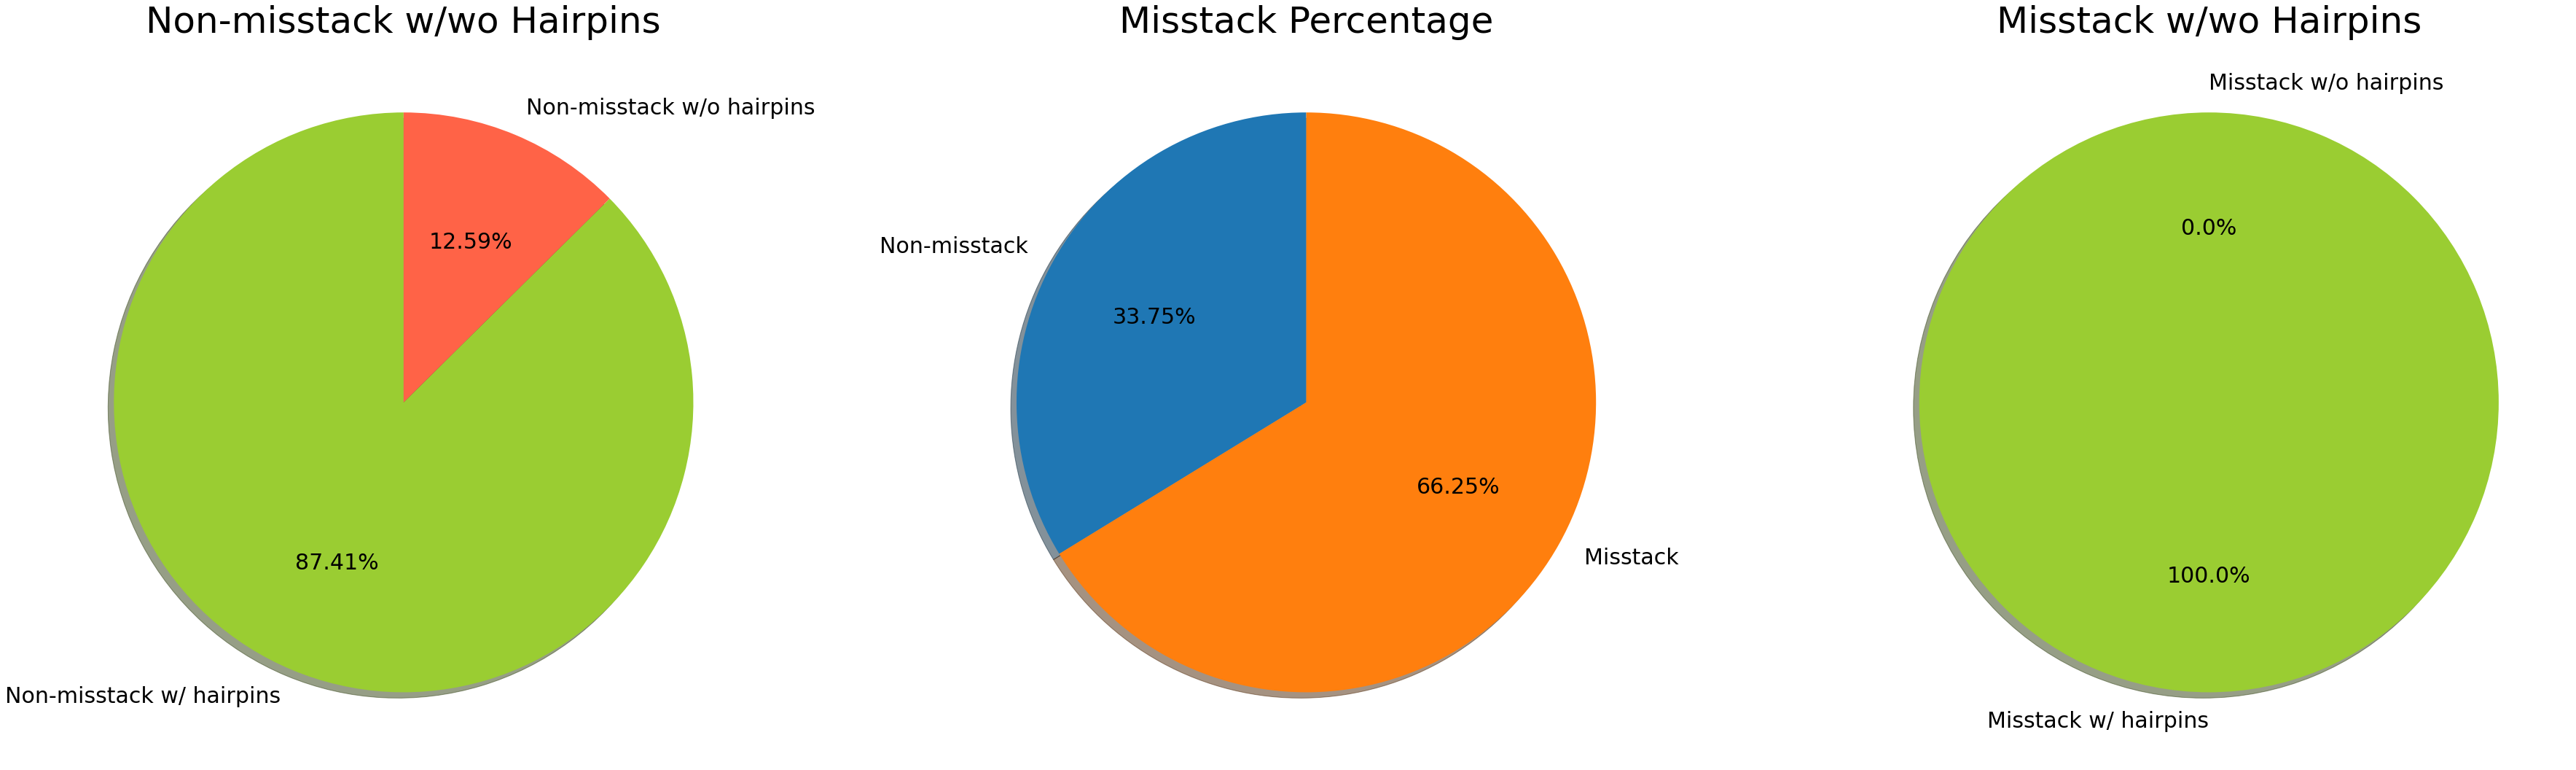

                                         265 hairpins in 265 Non-misstack reactions
                                         118 hairpins in 135 Non-misstack reactions


In [156]:
import matplotlib.pyplot as plt

# Data for the first pie chart
labels1 = ['Non-misstack', 'Misstack']
sizes1 = [traj_no_mismatch.shape[0], traj_mismatch.shape[0]]

# Data for the second pie chart
label2 = ['Non-misstack w/ hairpins', 'Non-misstack w/o hairpins']
size2 = [hp_nonmismatch_index.shape[0], traj_no_mismatch.shape[0] - hp_nonmismatch_index.shape[0]]

# Data for the third pie chart
label3 = ['Misstack w/ hairpins', 'Misstack w/o hairpins']
size3 = [hp_mismatch_index.shape[0], traj_mismatch.shape[0] - hp_mismatch_index.shape[0]]


fig, ax = plt.subplots(1, 3, figsize=(50, 30)) 
# First pie chart
color_hairpin = ['yellowgreen', 'tomato']
ax[0].pie(size2, labels=label2, autopct='%1.2f%%', shadow=True, startangle=90,  colors=color_hairpin, textprops={'fontsize': 30})
ax[0].set_title('Non-misstack w/wo Hairpins')
ax[0].title.set_size(50)
# Second pie chart
ax[1].pie(sizes1, labels=labels1, autopct='%1.2f%%', shadow=True, startangle=90, textprops={'fontsize': 30})
ax[1].set_title('Misstack Percentage')
# title size
ax[1].title.set_size(50)
# Third pie chart
ax[2].pie(size3, labels=label3, autopct='%1.1f%%', shadow=True, startangle=90, colors=color_hairpin, textprops={'fontsize': 30})
ax[2].set_title('Misstack w/wo Hairpins')
ax[2].title.set_size(50)
# Adjust the layout to prevent overlap
plt.tight_layout()
plt.show()

print(f'                                         {np.where(hairpinInmismatch==1)[0].shape[0]} hairpins in {traj_mismatch.shape[0]} Non-misstack reactions')
print(f'                                         {np.where(hairpinInmatch==1)[0].shape[0]} hairpins in {traj_no_mismatch.shape[0]} Non-misstack reactions')


/var/folders/z9/3zs_cg3x09n1q9fmthyx2x600000gn/T/ipykernel_93271/2802223611.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(time_names, fontsize=15)


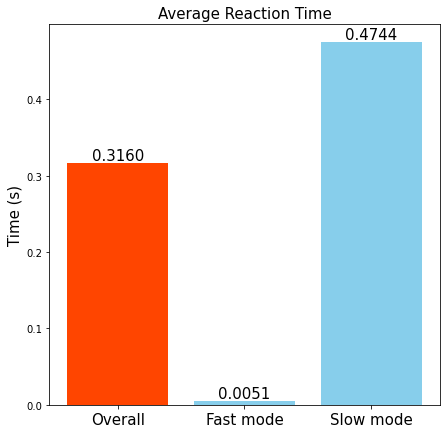

In [21]:
fig, ax = plt.subplots(figsize=(7,7))
time_names = ['Overall', 'Fast mode', 'Slow mode']
bar_colors = ['orangered', 'skyblue', 'skyblue']
average_times = [np.mean(rxnTimes), np.mean(rxnTimes[traj_no_mismatch]), np.mean(rxnTimes[traj_mismatch])]
bars = ax.bar(time_names, average_times, color=bar_colors)
ax.set_title('Average Reaction Time', fontsize=15)
ax.set_ylabel('Time (s)', fontsize=15)
ax.set_xticklabels(time_names, fontsize=15)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', ha='center', va='bottom', fontsize=15)


In [22]:
print("Conclusion: \n Hairpin structures severs as two roles:\n \
1. If hairpins form first, then they will prevent the reaction to form mismatches, speeding up the reaction.\n \
2. If mismatches happen first, then hairpins will serve as 'escape route', to help reaction trajectories \n \
   escape from the kinetic traps towards the final state. \n") 

Conclusion: 
 Hairpin structures severs as two roles:
 1. If hairpins form first, then they will prevent the reaction to form mismatches, speeding up the reaction.
 2. If mismatches happen first, then hairpins will serve as 'escape route', to help reaction trajectories 
    escape from the kinetic traps towards the final state. 



### PCA Variance

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [28]:
# Load embeddings

datafile='Machinek-PRF-trunc'

TNAME = '24-0324-0120'
CKPT = 'checkpoint_epoch_39'
# CKPT = 'model'

inpath5 = f'../data/post_data/{datafile}/model_config/{TNAME}/embed_{CKPT}_Machinek-PRF.npz'
loaded_data5 = np.load(inpath5, allow_pickle=True)
embeddings = loaded_data5['embeddings']
embeddings.max(), embeddings.min(), embeddings.mean(), embeddings.std()

(18.535126, -15.465101, -0.100150794, 2.7371447)

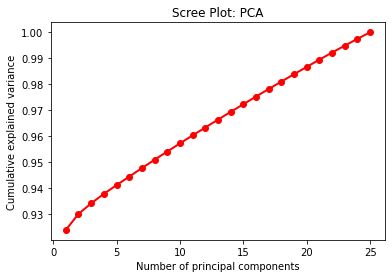

[0.9238547  0.93002415 0.9340898  0.93775463 0.9411008  0.94438595
 0.9476529  0.950886   0.95405656 0.9571719  0.9602631  0.9633008
 0.96633756 0.96931356 0.9722773  0.9752209  0.97813433 0.981011
 0.98385376 0.98666483 0.9894405  0.99219406 0.9948486  0.997461
 1.        ]


In [29]:
cm = PCA(n_components=25)
cm.fit(embeddings)

PC_values = np.arange(cm.n_components_) + 1
plt.plot(PC_values, np.cumsum(cm.explained_variance_ratio_), 'ro-', linewidth=2)
plt.title('Scree Plot: PCA')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance');
# plt.xticks(np.arange(0, data_embed.shape[-1]+1, 1))

plt.show()

print(np.cumsum(cm.explained_variance_ratio_))

## Machinek-MM14

### Time distribution plot

In [29]:
datafile = 'Machinek-Mismatch14'
rxnTimes, ids = loadTimeData(datafile)

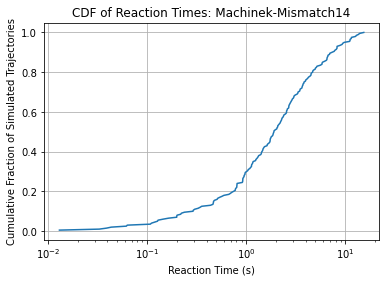

Max reaction time: 15.388087213733092 seconds
Min reaction time: 0.013110345685328458 seconds
Average reaction time: 3.013855969181078 seconds
Median reaction time: 1.9128896734942349 seconds


In [31]:
timeCDF(datafile, rxnTimes)

## Machinek-MM14C2T

In [32]:
datafile = 'Machinek-Mismatch14C2T'
rxnTimes, ids = loadTimeData(datafile)

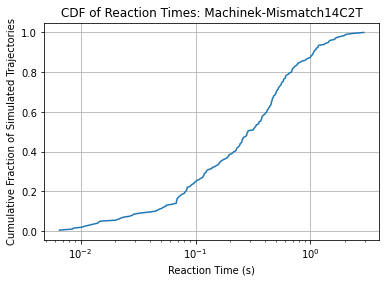

Max reaction time: 2.9118061595676443 seconds
Min reaction time: 0.0065370445307098 seconds
Average reaction time: 0.4420450385714598 seconds
Median reaction time: 0.28596644443911623 seconds


In [33]:
timeCDF(datafile, rxnTimes)

## Machinek-MM10

In [9]:
datafile = 'Machinek-Mismatch10'
rxnTimes, ids = loadTimeData(datafile)

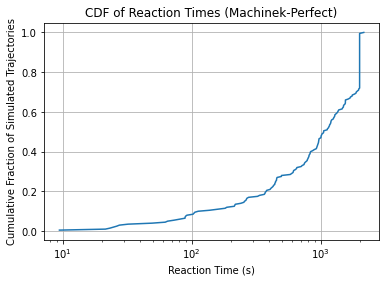

Max reaction time: 2154.546582464505 seconds
Min reaction time: 9.424768510880185 seconds
Average reaction time: 1133.9511061469436 seconds
Median reaction time: 1053.129848169549 seconds


In [10]:
timeCDF(datafile, rxnTimes)

## Machinek-MM2

In [34]:
datafile = 'Machinek-Mismatch2'
rxnTimes, ids = loadTimeData(datafile)

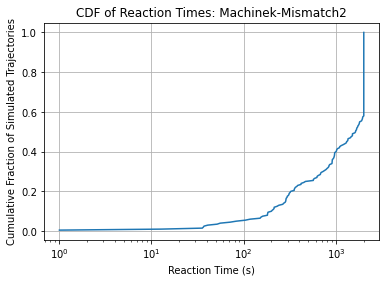

Max reaction time: 1999.9997478039215 seconds
Min reaction time: 1.0101684277319627 seconds
Average reaction time: 1293.6079721516098 seconds
Median reaction time: 1631.2280290475103 seconds


In [35]:
timeCDF(datafile, rxnTimes)

## Machinek-MM2C2A

In [36]:
datafile = 'Machinek-Mismatch2C2A'
rxnTimes, ids = loadTimeData(datafile)

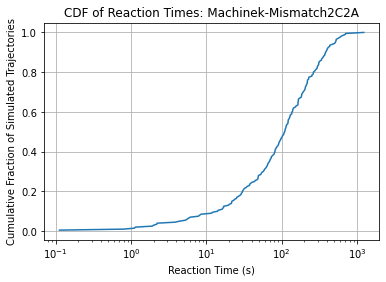

Max reaction time: 1226.958614059385 seconds
Min reaction time: 0.11202739362914928 seconds
Average reaction time: 162.16124787915433 seconds
Median reaction time: 109.8609716906621 seconds


In [37]:
timeCDF(datafile, rxnTimes)

## Machinek-MM2C2T

In [43]:
datafile = 'Machinek-Mismatch2C2T'
rxnTimes, ids = loadTimeData(datafile)

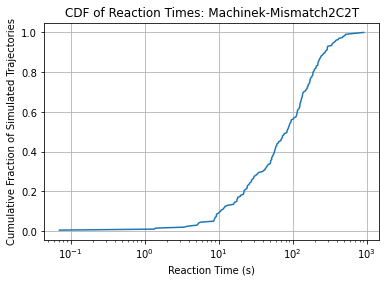

Max reaction time: 911.0958823240535 seconds
Min reaction time: 0.07078459897087473 seconds
Average reaction time: 120.41450636962047 seconds
Median reaction time: 83.9613165961955 seconds


In [39]:
timeCDF(datafile, rxnTimes)

## Detachment Probability

In [128]:
# datafile = 'Machinek-PRF'
datafile = 'Machinek-Mismatch2C2A'

trajs_states, trajs_shortnames = loadStateData(datafile)

In [129]:
set(trajs_shortnames[0]), set(trajs_shortnames[10])

({'incb+sub inv', 'inv+sub+incb'}, {'incb+sub inv', 'inv+sub+incb'})

In [130]:
count_list = []
for i in range(200):
    count_list.append(if_detachment(trajs_shortnames[i]))
    
prob = sum(np.array(count_list) == 1) / len(count_list)
prob

0.245

In [133]:
set(trajs_shortnames[1])

{'incb+sub inv', 'inv+sub+incb'}

## Jordan's data

In [2]:
import h5py as h5

def read_trajectory(traj_filename, sim_no): 
    with h5.File(traj_filename, "r") as f:
        times = f[str(sim_no)]["times"][:]
        energies = f[str(sim_no)]["energies"][:]
        structs = [s.decode() for s in f[str(sim_no)]["structs"]]
        ids = [s.decode() for s in f[str(sim_no)]["ordered_ids"]]
    return times, energies, structs, ids

In [3]:
fdata = '../data/raw_data/machinektest/perfect_toehold8_conc10_54222558.hdf5'

In [6]:
traj0 = read_trajectory(fdata, 0)

In [10]:
times = traj0[0]
times.shape, times[:5]

((161431,),
 array([0.00000000e+00, 6.34522909e-08, 8.06113779e-08, 8.06152278e-08,
        1.01840273e-07]))

In [11]:
energies = traj0[1]
energies.shape, energies[:5]

((161431,),
 array([-0.91701398,  2.42413224,  6.49062426,  2.84947804,  3.42481578]))

In [14]:
strucs = traj0[2]
len(strucs), strucs[:5]


(161431,
 ['((((((((((((((((+.....................(..+).........))))))))))))))))',
  '((((((((((((((((+..............(.....)(..+).........))))))))))))))))',
  '((((((((((((((((+(............)(.....)(..+).........))))))))))))))))',
  '((((((((((((((((+(............).......(..+).........))))))))))))))))',
  '((((((((((((((((+(............)....(..(..+).).......))))))))))))))))'])

In [15]:
ids = traj0[3]
len(ids), ids[:5]

(161431, ['4+2+0', '4+2+0', '4+2+0', '4+2+0', '4+2+0'])

In [16]:
traj555 = read_trajectory(fdata, 555)

In [17]:
traj555[3]

['3334+3332+3330', '3332+3330 3334']

In [18]:
traj555[2]

['((((((((((((((((+.........((.(....).)....+).........))))))))))))))))',
 '((((((((((((((((+..........)))))))))))))))) ..........(.(....).)....']

In [28]:
traj2 = read_trajectory(fdata, 2)

In [30]:
traj2[2], traj2[3]

(['((((((((((((((((+..........(.............+...)......))))))))))))))))',
  '((((((((((((((((+..........((............+.).)......))))))))))))))))',
  '((((((((((((((((+..........(.............+...)......))))))))))))))))',
  '((((((((((((((((+..........(.(...........+.).)......))))))))))))))))',
  '((((((((((((((((+............(...........+.)........))))))))))))))))',
  '((((((((((((((((+.........(..(...........+.)..).....))))))))))))))))',
  '((((((((((((((((+(.......)(..(...........+.)..).....))))))))))))))))',
  '((((((((((((((((+.........(..(...........+.)..).....))))))))))))))))',
  '((((((((((((((((+.........(..............+....).....))))))))))))))))',
  '((((((((((((((((+(.......)(..............+....).....))))))))))))))))',
  '((((((((((((((((+.........(..............+....).....))))))))))))))))',
  '((((((((((((((((+(.......)(..............+....).....))))))))))))))))',
  '((((((((((((((((+.........(..............+....).....))))))))))))))))',
  '((((((((((((((((+(.......)(........

### Jordan Data

In [22]:
import h5py as h5
import numpy

def read_trajectory(traj_filename, sim_no): 
    with h5.File(traj_filename, "r") as f:
        times = f[str(sim_no)]["times"][:]
        energies = f[str(sim_no)]["energies"][:]
        structs = [s.decode() for s in f[str(sim_no)]["structs"]]
        ids = [s.decode() for s in f[str(sim_no)]["ordered_ids"]]
    return times, energies, structs, ids

def parse_cids(cids):
  # decode strand IDs
  sids = [np.array(c.split(b'+'), dtype=int) // 2 for c in cids]
  smin = np.concatenate(sids).min()
  sids = [(c - smin).tolist() for c in sids]
  # find minimal cyclic permutation per complex
  prm_parts = lambda c: lambda p: (c[p:len(c)], c[0:p])
  prm = lambda c: lambda p: sum(prm_parts(c)(p), start=[])
  argprm = lambda c: min(np.atleast_1d(np.argmin(c)), key=prm(c))
  return [tuple(prm(c)(argprm(c))) for c in sids]

In [23]:
file = f'../data/raw_data/machinektest/perfect_toehold8.hdf5'
times, energies, structs, ids = read_trajectory(file, 5)

In [44]:
[parse_cids(cids.encode(encoding='utf-8').split(b' ')) for cids in [ids[0], ids[-1]]]

[[(0, 2, 1)], [(0,), (1, 2)]]

In [34]:
parse_cids(ids[0].encode(encoding='utf-8').split(b' '))

[(0, 2, 1)]

In [45]:
ids[-1], ids[-1].encode(encoding='utf-8'), ids[-1].encode(encoding='utf-8').split(b' ')

('30 34+32', b'30 34+32', [b'30', b'34+32'])

In [2]:
import re
import pickle
import gzip
import numpy as np
import matplotlib.pyplot as plt


def loadData(datafile):
    inpath = f'../data/post_data/{datafile}/preprocess_{datafile}.npz'
    loaded_data = np.load(inpath, allow_pickle=True)
    trans_time = loaded_data["trans_time"]
    
    inpath2 = f'../data/post_data/{datafile}/time_{datafile}.npz'
    loaded_data2 = np.load(inpath2, allow_pickle=True)
    trj_id = loaded_data2['trj_id']
    
    rxnTimes = trans_time[trj_id]
    
    inpath3 = f'../data/post_data/{datafile}/{datafile}.pkl.gz'
    with gzip.open(inpath3, 'rb') as file:
        loaded_data = pickle.load(file)
    trajs_states = loaded_data['trajs_states']

    return rxnTimes, trajs_states



def timeCDF(datafile, rxnTimes):
    
    sort_time = np.sort(rxnTimes)
    cumulative_fraction = np.arange(1, len(sort_time) + 1) / len(sort_time)

    plt.plot(sort_time, cumulative_fraction, '-', color='black', linewidth=2)
    plt.title(f'CDF of Reaction Times: {datafile}')
    # plt.title(f'CDF of Reaction Times (Machinek-Perfect)')
    
    plt.xlabel('Reaction Time (s)')
    plt.ylabel('Cumulative Fraction of Simulated Trajectories') 
    plt.xscale('log')
    plt.grid(True)
    plt.show()

    print('Max reaction time:', np.max(rxnTimes), 'seconds')
    print('Min reaction time:', np.min(rxnTimes), 'seconds')
    print('Average reaction time:', np.mean(rxnTimes), 'seconds')
    print('Median reaction time:', np.median(rxnTimes), 'seconds')
    # thres = np.float64(1e-2)
    # print(f'Number of reaction slower than {thres}:', np.where(rxnTimes > thres)[0].shape[0])
    # print(f'Number of reaction faster than {thres}:', np.where(rxnTimes < thres)[0].shape[0])
    
def misstack(sort_idx, sort_trajs_states):
    num_misstack = 0
    traj_idx = []
    for idx, traj in zip(sort_idx, sort_trajs_states):
        traj = trajs_states[idx]
        for states in traj:
            inv = states.split('+')[1]
            sub = states.split('+')[2]
            if inv[9:13].count('(') >= 3 and inv[13:24].count('.') >= 8 and sub[1:5].count(')') >= 3 and sub[5:10].count('.') >=2: 
                num_misstack += 1  
                traj_idx.append(idx)
                break       
    return num_misstack, traj_idx

In [11]:
datafile = 'distal_toehold8'
rxnTimes, trajs_states = loadData(datafile)
sort_idx = np.argsort(rxnTimes)[::-1]
sort_rxnTimes = rxnTimes[sort_idx]
sort_trajs_states = trajs_states[sort_idx]

In [12]:
num_succ = 0
sort_succ_traj_id = []
for idx, state in zip(sort_idx, sort_trajs_states):
    count_lp = state[-1].split('+')[0].count('(')
    count_rp = state[-1].split('+')[0].count(')')
    diff = abs(count_lp - count_rp)
    if diff == 1:
        sort_succ_traj_id.append(idx)
        num_succ += 1

print(datafile)
print('Total number of trajectories::', len(sort_trajs_states))
print('Number of successful trajectories:', num_succ)
print('Fraction of successful/unsuccessful:', round(num_succ / (len(sort_trajs_states)-num_succ), 3))
print('The index of successful trajectories:', sort_succ_traj_id)

rxnTimes_succ = rxnTimes[sort_succ_traj_id]
print('Mean reaction time:', round(np.mean(rxnTimes_succ),5), 'seconds')

# find how many misstacked trajectories
num_misstack, traj_idx = misstack(sort_idx, sort_trajs_states)

# find how many successful trajectories are misstacked
num_succ_misstack = 0
succ_misstack_idx = []
for idx in traj_idx:
    if idx in sort_succ_traj_id:
        succ_misstack_idx.append(idx)
        num_succ_misstack += 1

print('Number of successful misstacked trajectories:', num_succ_misstack, ':', succ_misstack_idx)
print('Total number of misstacked trajectories:', num_misstack) 

distal_toehold8
Total number of trajectories:: 300
Number of successful trajectories: 12
Fraction of successful/unsuccessful: 0.042
The index of successful trajectories: [146, 217, 92, 59, 86, 262, 8, 222, 53, 290, 274, 2]
Mean reaction time: 0.01488 seconds
Number of successful misstacked trajectories: 0 : []
Total number of misstacked trajectories: 13


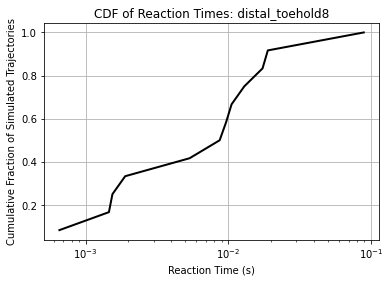

Max reaction time: 0.08934173794978477 seconds
Min reaction time: 0.0006562098861153601 seconds
Average reaction time: 0.014884399243546764 seconds
Median reaction time: 0.00919586575851565 seconds


In [13]:
rxnTimes_succ = rxnTimes[sort_succ_traj_id]
timeCDF(datafile, rxnTimes_succ)

In [14]:
rxnTimes_succ = rxnTimes[sort_succ_traj_id]
rxnTimes_succ

array([0.08934174, 0.01897593, 0.01743141, 0.01297779, 0.01056916,
       0.00967146, 0.00872027, 0.005368  , 0.00189749, 0.00154425,
       0.00145907, 0.00065621])